In [4]:
pip install duckdb pandas matplotlib

  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 7.2 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.9 MB 7.7 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.9 MB 8.0 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 8.2 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.9 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 7.9 MB/s  0:00:01
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.3 MB 9.4 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.3 MB 9.8 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 10.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 10.0 MB/s eta 0:00:01
   ----------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Step 1: Connecting to MotherDuck ---
Using MotherDuck connection: md:
Available tables in MotherDuck:
              table_name
0            customer_V2
1               sales_V2
2             product_V2
3              databases
4     database_snapshots
5           owned_shares
6          query_history
7         recent_queries
8         shared_with_me
9           storage_info
10  storage_info_history
11         sales_summary
12          top_products
Views created: sales_summary, top_products

--- Performance Observations ---
Query Execution Time: 0.1827 seconds
Data is loaded from MotherDuck, not local CSV files.

--- Step 4: Visualizing Top Products ---


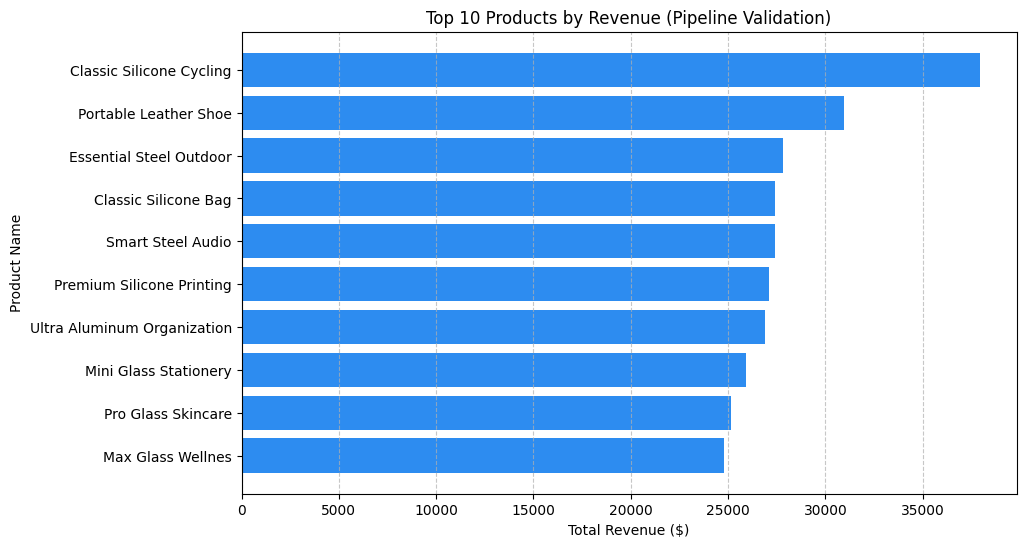

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

# 1. Initialize Connection to MotherDuck
# Ensure MOTHERDUCK_API_KEY is defined in your environment before running.
"""api_key = #os.getenv("MOTHERDUCK_API_KEY")
if not api_key:
    raise EnvironmentError("Please set MOTHERDUCK_API_KEY to connect to MotherDuck.")"""

con = duckdb.connect(database='md:my_db')

print("--- Step 1: Connecting to MotherDuck ---")
print("Using MotherDuck connection: md:")

# Confirm source tables exist in MotherDuck
available_tables = con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema='main'").df()
print("Available tables in MotherDuck:")
print(available_tables)

# --- Step 2: Create Analytical Views ---

# Sales Summary View
con.execute("""
CREATE OR REPLACE VIEW sales_summary AS
SELECT 
    order_date::DATE AS order_date,
    region,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(quantity) AS units_sold,
    ROUND(SUM(sales), 2) AS total_revenue
FROM sales_V2
GROUP BY ALL;
""")

# Top Products View (Joining on the complex ID mapping)
con.execute("""
CREATE OR REPLACE VIEW top_products AS
SELECT 
    p.product_name,
    p.product_category,
    ROUND(SUM(s.sales), 2) AS total_revenue,
    ROUND(SUM(s.profit), 2) AS total_profit,
    ROUND(AVG(p.product_ratings), 1) AS avg_rating
FROM sales_V2 s
JOIN product_V2 p 
  ON s.row_id = CAST(regexp_replace(p.product_id, '[^0-9]', '', 'g') AS INTEGER)
GROUP BY ALL
ORDER BY total_revenue DESC;
""")
print("Views created: sales_summary, top_products")

# --- Step 3: Performance & Storage Evaluation ---

start_time = time.time()
res_data = con.execute("SELECT * FROM top_products LIMIT 10").df()
perf_duration = time.time() - start_time

print(f"\n--- Performance Observations ---")
print(f"Query Execution Time: {perf_duration:.4f} seconds")
print("Data is loaded from MotherDuck, not local CSV files.")

# --- Step 4: Visualization ---

print("\n--- Visualizing Top Products ---")
plt.figure(figsize=(10, 6))
plt.barh(res_data['product_name'], res_data['total_revenue'], color='#2d8cf0')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Name')
plt.title('Top 10 Products by Revenue (Pipeline Validation)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


--- Step 5: Sales Summary Dashboard ---


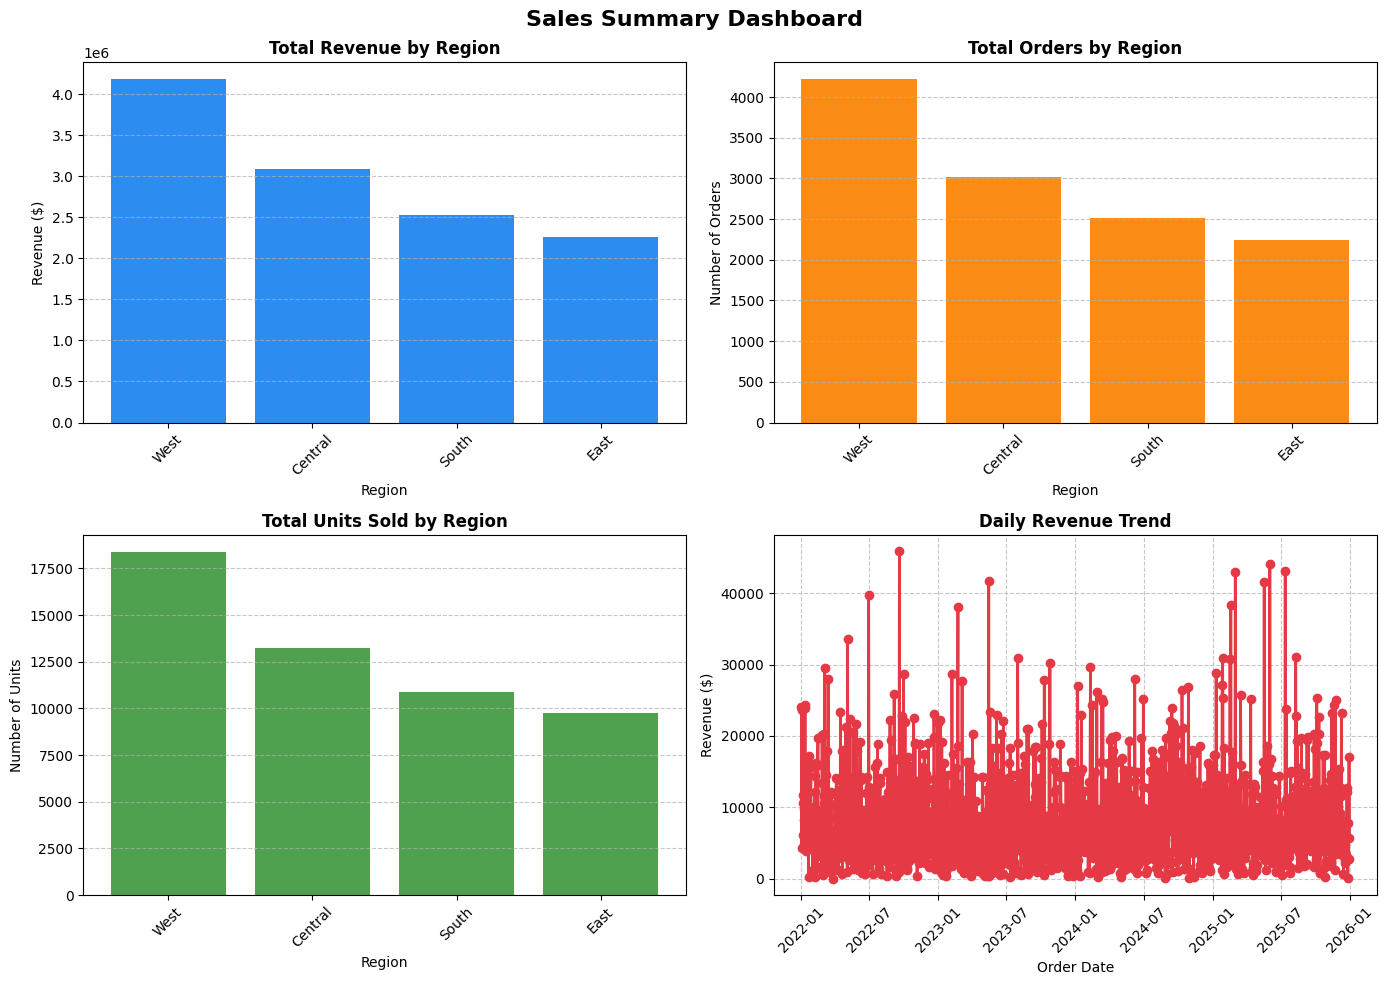


--- Summary Statistics ---
Total Revenue: $12,056,860.18
Total Orders: 12,000
Total Units Sold: 52,285
Average Order Value: $1,004.74


In [ ]:
# --- Step 5: Sales Summary Dashboard ---

print("\n--- Sales Summary Dashboard ---")

# Query sales summary data
sales_summary_data = con.execute("""
    SELECT * FROM sales_summary
    ORDER BY order_date DESC
""").df()

# Create a 2x2 dashboard for sales summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Summary Dashboard', fontsize=16, fontweight='bold')

# 1. Total Revenue by Region (Top Left)
region_revenue = con.execute("""
    SELECT region, ROUND(SUM(total_revenue), 2) AS total_revenue
    FROM sales_summary
    GROUP BY region
    ORDER BY total_revenue DESC
""").df()

axes[0, 0].bar(region_revenue['region'], region_revenue['total_revenue'], color='#2d8cf0')
axes[0, 0].set_title('Total Revenue by Region', fontweight='bold')
axes[0, 0].set_xlabel('Region')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Total Orders by Region (Top Right)
region_orders = con.execute("""
    SELECT region, SUM(total_orders) AS total_orders
    FROM sales_summary
    GROUP BY region
    ORDER BY total_orders DESC
""").df()

axes[0, 1].bar(region_orders['region'], region_orders['total_orders'], color='#fa8c16')
axes[0, 1].set_title('Total Orders by Region', fontweight='bold')
axes[0, 1].set_xlabel('Region')
axes[0, 1].set_ylabel('Number of Orders')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Units Sold by Region (Bottom Left)
region_units = con.execute("""
    SELECT region, SUM(units_sold) AS units_sold
    FROM sales_summary
    GROUP BY region
    ORDER BY units_sold DESC
""").df()

axes[1, 0].bar(region_units['region'], region_units['units_sold'], color='#50a14f')
axes[1, 0].set_title('Total Units Sold by Region', fontweight='bold')
axes[1, 0].set_xlabel('Region')
axes[1, 0].set_ylabel('Number of Units')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# 4. Revenue Trend Over Time (Bottom Right)
daily_revenue = con.execute("""
    SELECT order_date, SUM(total_revenue) AS daily_revenue
    FROM sales_summary
    GROUP BY order_date
    ORDER BY order_date
""").df()

axes[1, 1].plot(daily_revenue['order_date'], daily_revenue['daily_revenue'], marker='o', color='#e63946', linewidth=2)
axes[1, 1].set_title('Daily Revenue Trend', fontweight='bold')
axes[1, 1].set_xlabel('Order Date')
axes[1, 1].set_ylabel('Revenue ($)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n--- Summary Statistics ---")
total_revenue = sales_summary_data['total_revenue'].sum()
total_orders = sales_summary_data['total_orders'].sum()
total_units = sales_summary_data['units_sold'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {int(total_orders):,}")
print(f"Total Units Sold: {int(total_units):,}")
print(f"Average Order Value: ${(total_revenue / total_orders):,.2f}")
